# Task 4.2 — Single Strain HAI H3N2 A/Massachusetts/18/2022 (D28)

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

---

## Design notes

**Proxy target:** `HAI_H3N2 A/Massachusetts/18/2022_d28` does not exist as a column in the dataset. We use the row-wise mean of all H3N2 d28 HAI columns (`H3N2_proxy_d28`) as a stand-in — H3N2 strains within a season are highly correlated in titer response.

**Features:** All H3N2 d0 HAI columns (pre-vaccination titers for related H3N2 strains) + demographics. A generic sparsity filter would silently drop these because they're study-specific (many NaN), but they're the strongest predictors. H2O handles NaN natively.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import pyarrow

In [2]:
STRAIN = 'H3N2 A/Massachusetts/18/2022'
TARGET_COL = 'H3N2_proxy_d28'  # specific strain absent from dataset; proxy = row-mean of all H3N2 d28 columns
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [3]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [4]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [5]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — target coverage

`HAI_H3N2 A/Massachusetts/18/2022_d28` does not exist as a column in the dataset. Instead we build a proxy target: the row-wise mean of **all** H3N2 d28 HAI columns. Rows where no H3N2 d28 measurement exists at all are dropped.

The H3N2 d28 columns used to build the proxy are themselves dropped by the "Drop other-task target columns" step below, so there is no leakage.

In [6]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 110063)


In [7]:
h3n2_d28_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d28')]
print(f'Found {len(h3n2_d28_cols)} H3N2 d28 columns for proxy target.')
df[TARGET_COL] = df[h3n2_d28_cols].mean(axis=1)
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Found 25 H3N2 d28 columns for proxy target.
Filtered shape: (3568, 110064)


In [8]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 26510 all-null columns. New shape: (3568, 83554)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [9]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

String columns (5): ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']


In [10]:
for c in str_cols:
    print(f'  {c}: sample={df[c].dropna().unique()[:5].tolist()}')

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# Apply same coercion to challenge data so type mismatch can't crash predict()
challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
                          if c.startswith('HAI_')]
for c in challenge_hai_str_cols:
    challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

  participant_id: sample=['SDY269.SUB112836', 'SDY269.SUB112849', 'SDY269.SUB112854', 'SDY269.SUB112860', 'SDY269.SUB112881']
  PART_biological_sex: sample=['Female', 'Male']
  PART_race: sample=['White', 'Black', 'Asian', 'American Indian', 'Other']
  PART_geolocation: sample=['Georgia', 'Connecticut', 'Texas', 'California', 'Minnesota']
  PART_arm_name: sample=['Other', 'Standard Fluzone', 'High Dose Fluzone']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Coerced 0 HAI string columns in challenge data.


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with this specific target, some categorical features that vary across the full dataset (e.g. `PART_race`, `PART_geolocation`) may collapse to a single value here.

In [11]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 63 constant columns: ['FLOW_Classical monocytes_d0', 'FLOW_Conventional DC_d0', 'FLOW_Neutrophils + Basophils_d0', 'FLOW_Classical monocytes_d7', 'FLOW_Conventional DC_d7', 'FLOW_Neutrophils + Basophils_d7', 'TRAN_ENSG00000204695_d7', 'TRAN_ENSG00000225012_d7', 'TRAN_ENSG00000225203_d7', 'TRAN_ENSG00000232309_d7', 'TRAN_ENSG00000249491_d7', 'TRAN_ENSG00000254787_d7', 'TRAN_ENSG00000286232_d0', 'TRAN_ENSG00000286391_d0', 'TRAN_ENSG00000288723_d0', 'TRAN_ENSG00000290669_d0', 'TRAN_ENSG00000290855_d0', 'TRAN_ENSG00000290909_d0', 'TRAN_ENSG00000293350_d0', 'TRAN_ENSG00000293876_d0', 'TRAN_ENSG00000294500_d0', 'TRAN_ENSG00000295176_d0', 'TRAN_ENSG00000295371_d0', 'TRAN_ENSG00000296345_d0', 'TRAN_ENSG00000298439_d0', 'TRAN_ENSG00000299622_d0', 'TRAN_ENSG00000300583_d0', 'TRAN_ENSG00000301618_d0', 'TRAN_ENSG00000302139_d0', 'TRAN_ENSG00000302927_d0', 'TRAN_ENSG00000305446_d0', 'TRAN_ENSG00000306888_d0', 'TRAN_ENSG00000307065_d0', 'TRAN_ENSG00000307366_d0', 'TRAN_ENSG00000307986_d0', '

### Explicit feature selection

A generic `>50% missing` sparsity filter would silently drop nearly all H3N2 d0 columns — they're measured per-study so many rows are NaN, but they're the strongest predictors (pre-vaccination titer for related H3N2 strains is the dominant signal for d28 response). Instead we explicitly select:

- All **H3N2 d0** HAI columns (pre-vaccination titers for related H3N2 strains)
- All **demographic** columns (`PART_*`)

Transcriptomics, flow cytometry, and non-H3N2 HAI columns are dropped — they don't survive sparsity filtering anyway and add no signal here. H2O handles the remaining NaN values in H3N2 d0 columns natively at each split.

In [12]:
h3n2_d0_cols = [c for c in df.columns if 'H3N2' in c and c.endswith('_d0')]
part_cols = [c for c in df.columns if c.startswith('PART_')]

keep_cols = ['participant_id', TARGET_COL] + h3n2_d0_cols + part_cols
df = df[keep_cols]
print(f'Selected {len(h3n2_d0_cols)} H3N2 d0 features + {len(part_cols)} demographic features.')
print(f'Shape: {df.shape}')

# Force float64 on all H3N2 d0 columns in both training and challenge data.
# Sparse columns (few non-null values) can be mistyped as categorical by H2O,
# causing a type mismatch at predict() time when the challenge set has actual values.
for c in h3n2_d0_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print('Forced float64 on H3N2 d0 columns in training and challenge data.')

Selected 25 H3N2 d0 features + 5 demographic features.
Shape: (3568, 32)
Forced float64 on H3N2 d0 columns in training and challenge data.


In [13]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (3568, 32)
Target (H3N2_proxy_d28) stats (log2):
count    3568.000000
mean        5.860525
std         2.024357
min         0.000000
25%         4.321928
50%         5.946928
75%         7.321928
max        14.321928
Name: H3N2_proxy_d28, dtype: float64

dtype counts:
float64    27
str         5
Name: count, dtype: int64


---
## AutoML Setup

In [14]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-25.0.2+10 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\User\AppData\Local\Temp\tmp16fr7126
  JVM stdout: C:\Users\User\AppData\Local\Temp\tmp16fr7126\h2o_User_started_from_python.out
  JVM stderr: C:\Users\User\AppData\Local\Temp\tmp16fr7126\h2o_User_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_User_n2czy2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.41 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [15]:
# Explicitly type all H3N2 d0 columns as 'real' so H2O doesn't mistype
# sparsely-populated columns as categorical
h3n2_col_types = {c: 'real' for c in h3n2_d0_cols}
data = h2o.H2OFrame(df, column_types=h3n2_col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (3568, 32)


---
## AutoML Training

In [16]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 3568  |  Features: 30
Training complete.


In [17]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_1_20260509_...,1.172100,1.373819,0.859800,0.194974,1.373819
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,1.176598,1.384382,0.864939,0.195599,1.384382
2,GBM_3_AutoML_1_20260509_152338,1.182279,1.397784,0.865246,0.196316,1.397784
3,GBM_2_AutoML_1_20260509_152338,1.183169,1.399890,0.869447,0.196176,1.399890
4,GBM_5_AutoML_1_20260509_152338,1.183733,1.401224,0.867497,0.196931,1.401224
5,GBM_4_AutoML_1_20260509_152338,1.186876,1.408675,0.869887,0.196879,1.408675
6,GBM_grid_1_AutoML_1_20260509_152338_model_1,1.193061,1.423395,0.876015,0.198598,1.423395
7,GBM_1_AutoML_1_20260509_152338,1.206571,1.455813,0.887450,0.199689,1.455813
8,XRT_1_AutoML_1_20260509_152338,1.208510,1.460496,0.887277,0.200486,1.460496
9,DRF_1_AutoML_1_20260509_152338,1.227362,1.506417,0.890899,0.203359,1.506417


In [18]:
# Grab the best base model (skipping ensembles)
best_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_model = h2o.get_model(best_base_model_id)

cv_preds = top_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.2 — Spearman (Best Base Model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Task 4.2 — Spearman (Best Base Model 5-fold CV): 0.807  (p=0.0000)


Leader model: GBM_3_AutoML_1_20260509_152338


,variable,relative_importance,scaled_importance,percentage
0,PART_geolocation,9145.308594,1.000000,0.178469
1,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,8803.082031,0.962579,0.171790
2,HAI_H3N2 A/Brisbane/10/2007_d0,6159.253418,0.673488,0.120197
3,HAI_H3N2 A/Perth/16/2009_d0,5735.205078,0.627120,0.111921
4,PART_age,3216.031006,0.351659,0.062760
5,HAI_H3N2 A/South Australia/34/2019_d0,2708.001221,0.296108,0.052846
6,HAI_H3N2 A/Uruguay/716/2007_d0,2647.797363,0.289525,0.051671
7,HAI_H3N2 A/Victoria/361/2011_d0,2631.500000,0.287743,0.051353
8,HAI_H3N2 A/Hong Kong/2671/2019_d0,2422.190430,0.264856,0.047269
9,HAI_H3N2 A/Texas/50/2012_d0,973.537476,0.106452,0.018998


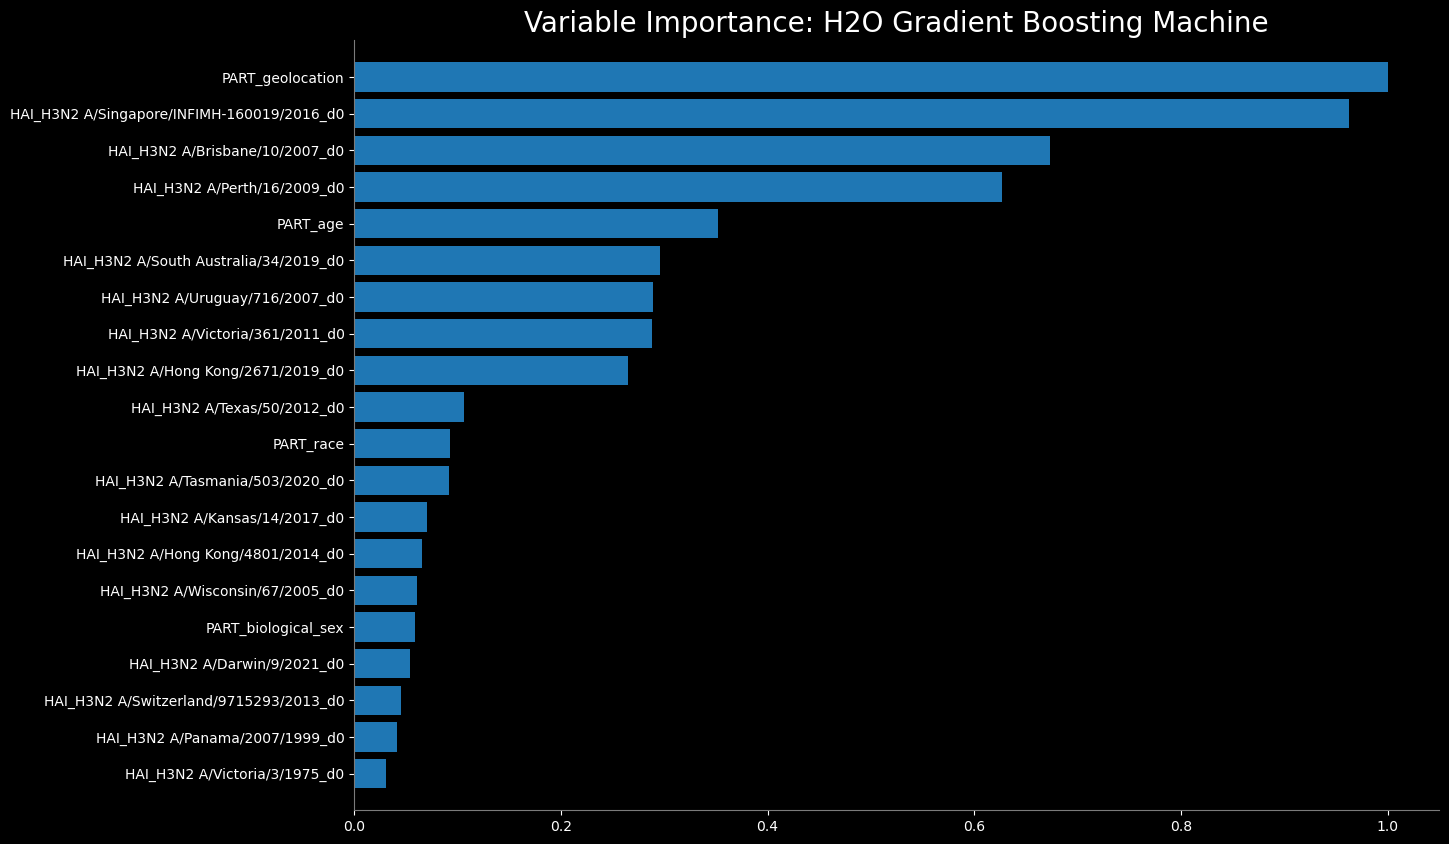

<Figure size 640x480 with 0 Axes>

In [19]:
print(f'Leader model: {top_model.model_id}')
varimp = top_model.varimp(use_pandas=True)
display(varimp.head(20))
top_model.varimp_plot(num_of_features=20)

In [20]:
challenge_col_types = {c: 'real' for c in h3n2_d0_cols if c in challenge_data.columns}
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_2.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,27.223796
1,2024_UGA.ID_086,11.797602
2,2024_UGA.ID_128,360.442218
3,2024_UGA.ID_170,34.187189
4,2024_UGA.ID_179,29.908045
5,2024_UGA.ID_215,160.708177
6,2024_UGA.ID_219,25.850268
7,2024_UGA.ID_275,17.565150
8,2024_UGA.ID_295,14.771463
9,2024_UGA.ID_296,9.401017


In [21]:
model_path = h2o.save_model(model=top_model, path='.', filename='model_4.2', force=True)
print(f'Model saved to: {model_path}')

Model saved to: C:\Users\User\repos\cmi-flu-prediction-challenge-capstone\automl_models\model_4.2


In [22]:
h2o.cluster().shutdown()

H2O session _sid_b79e closed.


---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)
- **Model saved:** `automl_models/model_4.2`

**Target:** Proxy = row-wise mean of all H3N2 d28 HAI columns (`H3N2_proxy_d28`). The specific strain `HAI_H3N2 A/Massachusetts/18/2022_d28` is absent from the dataset.

**Imputation note:** No manual imputation is applied. H2O's tree models (GBM, XRT, DRF) handle `NaN` natively at each split during training and prediction, including inside CV folds.

Submission saved to `automl_submission/task_4_2.csv` (raw titer scale via `np.exp2`).

To reload the model: `h2o.load_model('automl_models/model_4.2')`